# Tasmania Surf Conditions — Monthly Wave & Shark Activity Analysis

> *Make a notebook for Tasmanian surf conditions with wave period/energy and a windrose (wave rose), showing monthly average conditions to identify the best surf months, filtering out drifting buoys, and including shark activity data to help avoid big sharks.*

In [1]:
import os, requests, importlib.util, warnings
warnings.filterwarnings('ignore')

open('setup.py', 'w').write(
    requests.get(
        'https://raw.githubusercontent.com/aodn/aodn_cloud_optimised/main/notebooks/setup.py'
    ).text
)
spec = importlib.util.spec_from_file_location('setup', 'setup.py')
setup = importlib.util.module_from_spec(spec)
spec.loader.exec_module(setup)
setup.install_requirements()
setup.load_dataquery()

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from DataQuery import GetAodn, plot_ts_diagram

aodn = GetAodn()

✅ Virtual environment already exists, skipping creation.


Using Python 3.12.11 environment at: /home/lbesnard/miniforge3/envs/AodnCloudOptimised
Resolved 241 packages in 592ms
Audited 241 packages in 5ms


✅ Local version 0.3.9 is up to date (remote: 0.3.9)


# Tasmania Surf Conditions — Monthly Analysis

This notebook analyses fixed wave buoy data off Tasmania to identify the best surf months by wave height, peak period, and wave energy. A **wave rose** shows dominant swell directions. Drifting buoys are automatically excluded.

Bonus: acoustic shark detection data (IMOS Animal Tracking) is overlaid to highlight months with elevated shark activity near Tasmanian coasts — so you can plan accordingly! 🦈

**Datasets used:**
- [`wave_buoy_realtime_nonqc`](https://catalogue-imos.aodn.org.au/geonetwork/srv/eng/catalog.search#/metadata/b299cdcd-3dee-48aa-abdd-e0fcdbb9cadc) — near real-time wave buoy observations
- [`animal_acoustic_tracking_delayed_qc`](https://catalogue-imos.aodn.org.au/geonetwork/srv/eng/catalog.search#/metadata/541d4f15-122a-443d-ab4e-2b5feb08d6a0) — IMOS acoustic telemetry (sharks, 2007–2017)

## 1. Load Wave Buoy Data

In [2]:

from DataQuery import GetAodn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import calendar
import warnings
warnings.filterwarnings('ignore')

aodn = GetAodn()

# Tasmania bounding box
LAT_MIN, LAT_MAX = -45, -39
LON_MIN, LON_MAX = 143, 150

wave_ds = aodn.get_dataset("wave_buoy_realtime_nonqc.parquet")
print("Wave buoy temporal extent:", wave_ds.get_temporal_extent())

Wave buoy temporal extent: (Timestamp('2022-09-01 00:02:20'), Timestamp('2026-03-26 01:05:00'))


In [3]:

# Load all available Tasmania-area wave data
df_raw = wave_ds.get_data(
    date_start='2022-09-01', date_end='2026-04-01',
    lat_min=LAT_MIN, lat_max=LAT_MAX,
    lon_min=LON_MIN, lon_max=LON_MAX
)
print(f"Raw records: {len(df_raw)}")
print("Sites found:", df_raw['site_name'].unique())

2026-03-26 13:00:56,216 - aodn.GetAodn - INFO - Retrieving metadata for aodn-cloud-optimised/wave_buoy_realtime_nonqc.parquet


Raw records: 54375
Sites found: ['Cape Sorell' 'IndentedHead' 'STORM-BAY' 'WILSONS-PROM' 'Wilsons Prom']


### Filter out drifting buoys

Wave buoys can be anchored (moored) or drifting. A drifting buoy will show significant variability in its reported lat/lon. We detect drifters by computing the standard deviation of position per site — a std > 0.05° is a strong indicator of a drifting platform.

In [4]:

DRIFT_THRESHOLD = 0.05  # degrees — buoys with position std > this are considered drifters

pos_std = df_raw.groupby('site_name')[['LATITUDE', 'LONGITUDE']].std()
pos_std['max_std'] = pos_std[['LATITUDE', 'LONGITUDE']].max(axis=1)
pos_std['is_drifter'] = pos_std['max_std'] > DRIFT_THRESHOLD

print("Position variability per site (std in degrees):")
print(pos_std[['LATITUDE', 'LONGITUDE', 'is_drifter']].to_string())

fixed_sites = pos_std[~pos_std['is_drifter']].index.tolist()
drifting_sites = pos_std[pos_std['is_drifter']].index.tolist()
print(f"\n✅ Fixed buoys:    {fixed_sites}")
print(f"🚫 Drifting buoys: {drifting_sites}")

Position variability per site (std in degrees):
              LATITUDE  LONGITUDE  is_drifter
site_name                                    
Cape Sorell   0.000000   0.000000       False
IndentedHead  0.202692   0.273803        True
STORM-BAY     0.000138   0.000126       False
WILSONS-PROM  0.000511   0.000778       False
Wilsons Prom  0.261292   0.506734        True

✅ Fixed buoys:    ['Cape Sorell', 'STORM-BAY', 'WILSONS-PROM']
🚫 Drifting buoys: ['IndentedHead', 'Wilsons Prom']


In [5]:

# Keep only fixed buoys
df = df_raw[df_raw['site_name'].isin(fixed_sites)].copy()

# Apply quality control: keep only good-quality wave records
df = df[df['WAVE_quality_control'].isin([1, 2])].copy()

# Add time helpers
df['TIME'] = pd.to_datetime(df['TIME'])
df['month'] = df['TIME'].dt.month
df['year'] = df['TIME'].dt.year

# Wave energy proxy: E ∝ Hs²  (proportional to spectral energy, units m²)
# Using WHTH (significant wave height from time domain)
df['wave_energy_proxy'] = df['WHTH'] ** 2

print(f"Records after QC and drifter filter: {len(df)}")
print(f"Fixed sites: {df['site_name'].unique()}")
print(df[['TIME', 'site_name', 'WHTH', 'WPPE', 'WPMH', 'WPDI', 'wave_energy_proxy']].head())

Records after QC and drifter filter: 26129
Fixed sites: ['Cape Sorell' 'STORM-BAY' 'WILSONS-PROM']
                 TIME    site_name  WHTH  WPPE  WPMH   WPDI  wave_energy_proxy
0 2022-11-06 03:30:00  Cape Sorell  2.16  12.5   7.0  224.0             4.6656
1 2022-11-06 04:30:00  Cape Sorell  2.29  15.4   7.2  232.0             5.2441
2 2022-11-06 05:30:00  Cape Sorell  2.35  13.3   7.3  220.0             5.5225
3 2022-11-06 06:30:00  Cape Sorell  2.06  14.3   7.0  224.0             4.2436
4 2022-11-06 07:30:00  Cape Sorell  2.09  15.4   7.4  236.0             4.3681


## 2. Monthly Wave Statistics

Monthly median wave height, peak period, mean period, and wave energy proxy — averaged across all available years.

In [6]:

# Monthly medians
monthly = df.groupby('month').agg(
    Hs_median   =('WHTH', 'median'),
    Hs_p75      =('WHTH', lambda x: x.quantile(0.75)),
    Hs_p25      =('WHTH', lambda x: x.quantile(0.25)),
    WPPE_median =('WPPE', 'median'),
    WPMH_median =('WPMH', 'median'),
    energy_median=('wave_energy_proxy', 'median'),
    n_obs       =('WHTH', 'count'),
).reset_index()

monthly['month_abbr'] = monthly['month'].apply(lambda m: calendar.month_abbr[m])

print(monthly[['month_abbr', 'Hs_median', 'WPPE_median', 'WPMH_median', 'energy_median', 'n_obs']].to_string(index=False))

month_abbr  Hs_median  WPPE_median  WPMH_median  energy_median  n_obs
       Jan       2.22         11.8          7.6         4.9284   2877
       Feb       2.68         12.5          7.9         7.1824   2660
       Mar       2.82         12.5          8.3         7.9524   2750
       Apr       3.01         13.3          8.4         9.0601   2017
       May       3.22         13.3          8.3        10.3684   2179
       Jun       2.68         13.3          8.2         7.1824   1216
       Jul       2.79         13.3          9.3         7.7841    111
       Aug       3.32         13.3          8.1        11.0224   2166
       Sep       3.89         12.5          8.1        15.1321   1857
       Oct       3.18         12.5          7.8        10.1124   1840
       Nov       2.67         12.5          7.9         7.1289   2680
       Dec       2.42         11.8          7.4         5.8564   2616


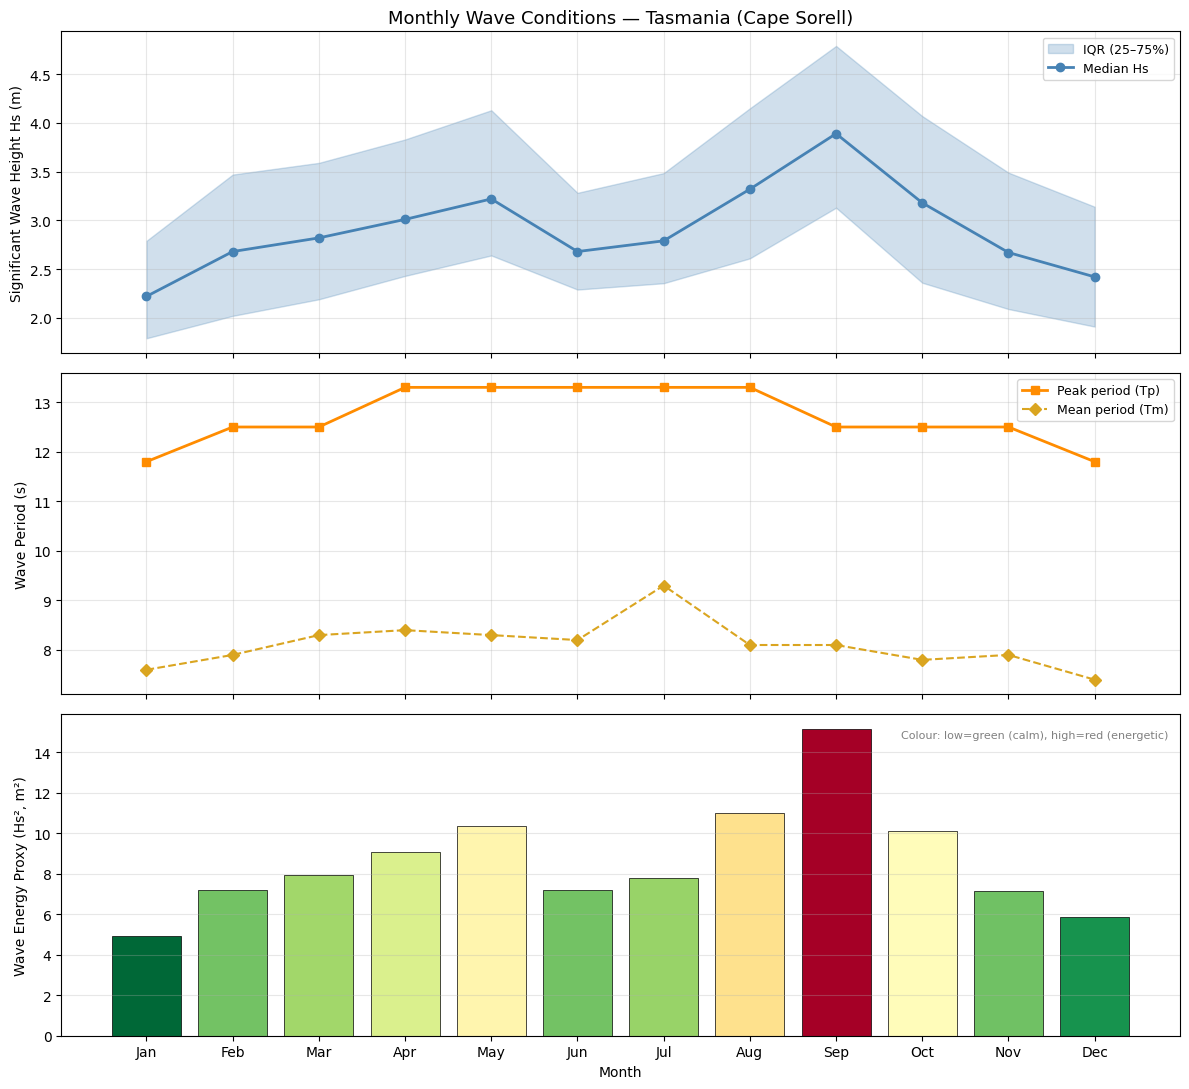

In [7]:

fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)
months = monthly['month'].values
xlabels = [calendar.month_abbr[m] for m in months]

# --- Panel 1: Significant wave height ---
ax = axes[0]
ax.fill_between(months, monthly['Hs_p25'], monthly['Hs_p75'],
                alpha=0.25, color='steelblue', label='IQR (25–75%)')
ax.plot(months, monthly['Hs_median'], 'o-', color='steelblue', lw=2, label='Median Hs')
ax.set_ylabel('Significant Wave Height Hs (m)', fontsize=10)
ax.set_title('Monthly Wave Conditions — Tasmania (Cape Sorell)', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Panel 2: Wave period ---
ax = axes[1]
ax.plot(months, monthly['WPPE_median'], 's-', color='darkorange', lw=2, label='Peak period (Tp)')
ax.plot(months, monthly['WPMH_median'], 'D--', color='goldenrod', lw=1.5, label='Mean period (Tm)')
ax.set_ylabel('Wave Period (s)', fontsize=10)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Panel 3: Wave energy proxy ---
ax = axes[2]
colors = cm.RdYlGn_r(
    (monthly['energy_median'] - monthly['energy_median'].min()) /
    (monthly['energy_median'].max() - monthly['energy_median'].min() + 1e-9)
)
bars = ax.bar(months, monthly['energy_median'], color=colors, edgecolor='k', linewidth=0.5)
ax.set_ylabel('Wave Energy Proxy (Hs², m²)', fontsize=10)
ax.set_xlabel('Month', fontsize=10)
ax.set_xticks(months)
ax.set_xticklabels(xlabels)
ax.grid(True, alpha=0.3, axis='y')
ax.text(0.99, 0.95, 'Colour: low=green (calm), high=red (energetic)',
        transform=ax.transAxes, ha='right', va='top', fontsize=8, color='gray')

fig.tight_layout()
plt.show()

## 3. Wave Rose (Dominant Swell Direction by Month)

A wave rose shows the distribution of dominant wave directions, coloured by wave height. This helps identify the predominant swell windows for each season.

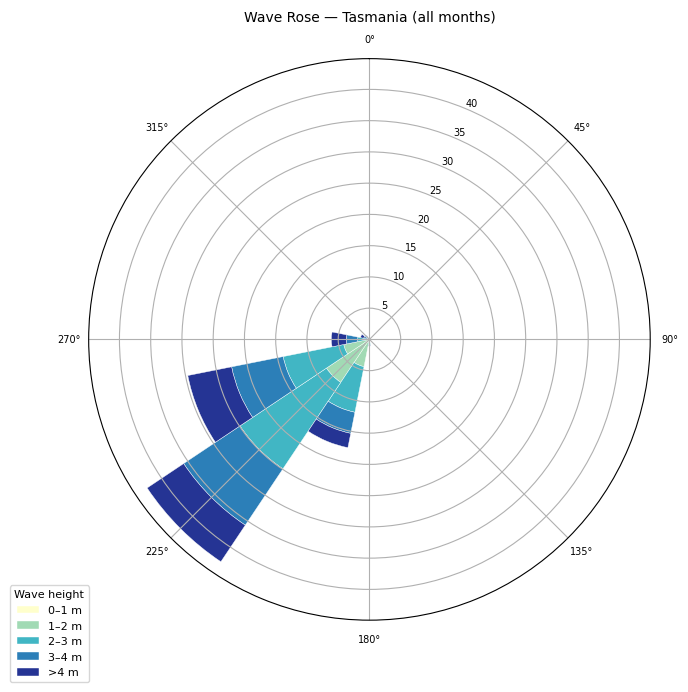

In [8]:

def plot_wave_rose(ax, directions, heights, title='Wave Rose', bins=16, height_bins=None):
    """
    Plot a wave rose on a polar axis.
    directions: degrees (oceanographic convention — direction FROM which waves come)
    heights: wave heights (m) for binning/colouring
    """
    if height_bins is None:
        height_bins = [0, 1, 2, 3, 4, np.inf]
    labels = ['0–1 m', '1–2 m', '2–3 m', '3–4 m', '>4 m']
    colours = ['#ffffcc', '#a1dab4', '#41b6c4', '#2c7fb8', '#253494']

    # Directional bins (N=0°, clockwise)
    dir_bins = np.linspace(0, 360, bins + 1)
    bin_width = 2 * np.pi / bins
    dir_centres = np.deg2rad(np.linspace(0, 360, bins, endpoint=False))

    valid = ~(np.isnan(directions) | np.isnan(heights))
    d = np.array(directions[valid])
    h = np.array(heights[valid])
    total = len(d)

    bottoms = np.zeros(bins)
    for i, (lo, hi) in enumerate(zip(height_bins[:-1], height_bins[1:])):
        mask = (h >= lo) & (h < hi)
        counts, _ = np.histogram(d[mask], bins=dir_bins)
        freqs = counts / max(total, 1) * 100
        ax.bar(dir_centres, freqs, width=bin_width, bottom=bottoms,
               color=colours[i], label=labels[i], edgecolor='white', linewidth=0.3, align='center')
        bottoms += freqs

    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_title(title, fontsize=10, pad=10)
    ax.tick_params(labelsize=7)

# Overall wave rose — all months combined
df_rose = df[df['WPDI'].notna() & df['WHTH'].notna()].copy()

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(7, 7))
plot_wave_rose(ax, df_rose['WPDI'], df_rose['WHTH'], title='Wave Rose — Tasmania (all months)')
handles, lbls = ax.get_legend_handles_labels()
ax.legend(handles, lbls, loc='lower left', bbox_to_anchor=(-0.15, -0.12),
          fontsize=8, title='Wave height', title_fontsize=8)
fig.tight_layout()
plt.show()

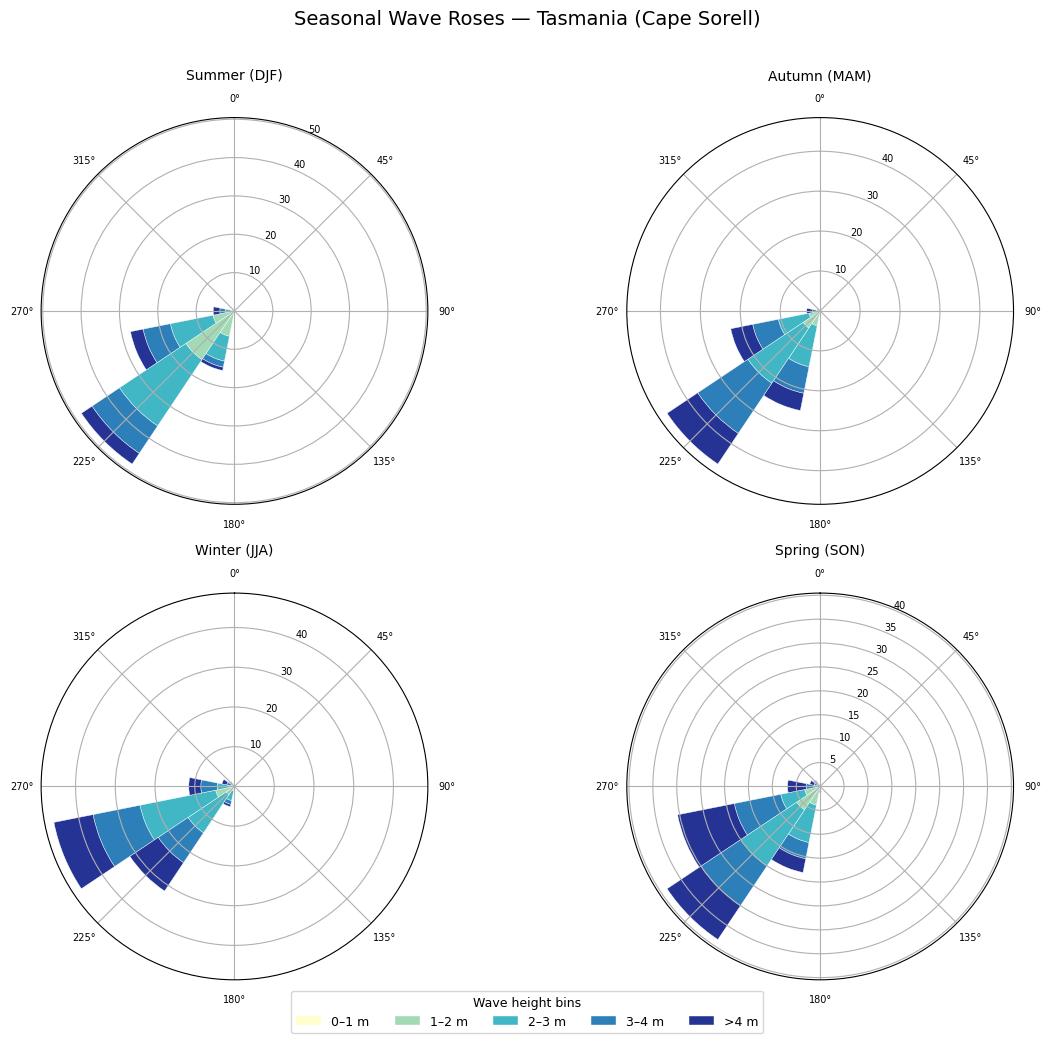

In [9]:

# Seasonal wave roses: Summer (DJF), Autumn (MAM), Winter (JJA), Spring (SON)
seasons = {
    'Summer (DJF)': [12, 1, 2],
    'Autumn (MAM)': [3, 4, 5],
    'Winter (JJA)': [6, 7, 8],
    'Spring (SON)': [9, 10, 11],
}

fig, axes = plt.subplots(2, 2, subplot_kw={'projection': 'polar'}, figsize=(12, 10))
axes_flat = axes.flatten()

for idx, (season_name, months_list) in enumerate(seasons.items()):
    ax = axes_flat[idx]
    mask = df_rose['month'].isin(months_list)
    sub = df_rose[mask]
    plot_wave_rose(ax, sub['WPDI'], sub['WHTH'], title=season_name)

handles, lbls = axes_flat[-1].get_legend_handles_labels()
fig.legend(handles, lbls, loc='lower center', ncol=5, fontsize=9,
           title='Wave height bins', title_fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle('Seasonal Wave Roses — Tasmania (Cape Sorell)', fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## 4. Shark Activity near Tasmania

Using IMOS acoustic telemetry data (2007–2017), we count monthly detections of tagged sharks and other large marine animals around Tasmania. The dominant tracked species here are **broadnose sevengill sharks** (*Notorynchus cepedianus*) — a large coastal predatory shark found in Tasmanian bays and estuaries.

> ⚠️ Note: detection counts reflect both animal abundance *and* receiver coverage. Low detections do not necessarily mean no sharks are present.

In [10]:

shark_ds = aodn.get_dataset("animal_acoustic_tracking_delayed_qc.parquet")
print("Shark tracking temporal extent:", shark_ds.get_temporal_extent())

Shark tracking temporal extent: (Timestamp('2007-11-18 08:35:14'), Timestamp('2017-03-17 13:29:21'))


In [11]:

df_sharks = shark_ds.get_data(
    date_start='2008-01-01', date_end='2017-12-31',
    lat_min=-45, lat_max=-39, lon_min=143, lon_max=150,
    lat_varname='latitude', lon_varname='longitude'
)
print(f"Total detections in Tasmania area: {len(df_sharks)}")
print("Installations:", df_sharks['installation_name'].unique())

2026-03-26 13:02:08,089 - aodn.GetAodn - INFO - Retrieving metadata for aodn-cloud-optimised/animal_acoustic_tracking_delayed_qc.parquet


Total detections in Tasmania area: 77552
Installations: ['Seven Gill tracking in Coastal Tasmania' 'Cape Barron Island'
 'Maria Island Line']


In [12]:

# Keep only good-quality detections
df_sharks = df_sharks[df_sharks['Detection_QC'] == 1].copy()

df_sharks['detection_timestamp'] = pd.to_datetime(df_sharks['detection_timestamp'])
df_sharks['month'] = df_sharks['detection_timestamp'].dt.month
df_sharks['year']  = df_sharks['detection_timestamp'].dt.year

# Monthly detection counts (normalised per year-month to account for uneven deployment)
monthly_sharks = df_sharks.groupby(['month', 'installation_name']).size().reset_index(name='detections')

# Also aggregate by month only
monthly_sharks_total = df_sharks.groupby('month').agg(
    detections=('detection_timestamp', 'count'),
    unique_tags=('transmitter_id', 'nunique'),
).reset_index()
monthly_sharks_total['month_abbr'] = monthly_sharks_total['month'].apply(lambda m: calendar.month_abbr[m])

print(monthly_sharks_total[['month_abbr', 'detections', 'unique_tags']].to_string(index=False))

month_abbr  detections  unique_tags
       Jan        3885           31
       Feb       11445           45
       Mar       23484           44
       Apr       11885           47
       May        6150           40
       Jun        5329           21
       Jul        2416           18
       Aug        2606           24
       Sep        1281           22
       Oct        1956           19
       Nov        1696           33
       Dec        2447           23


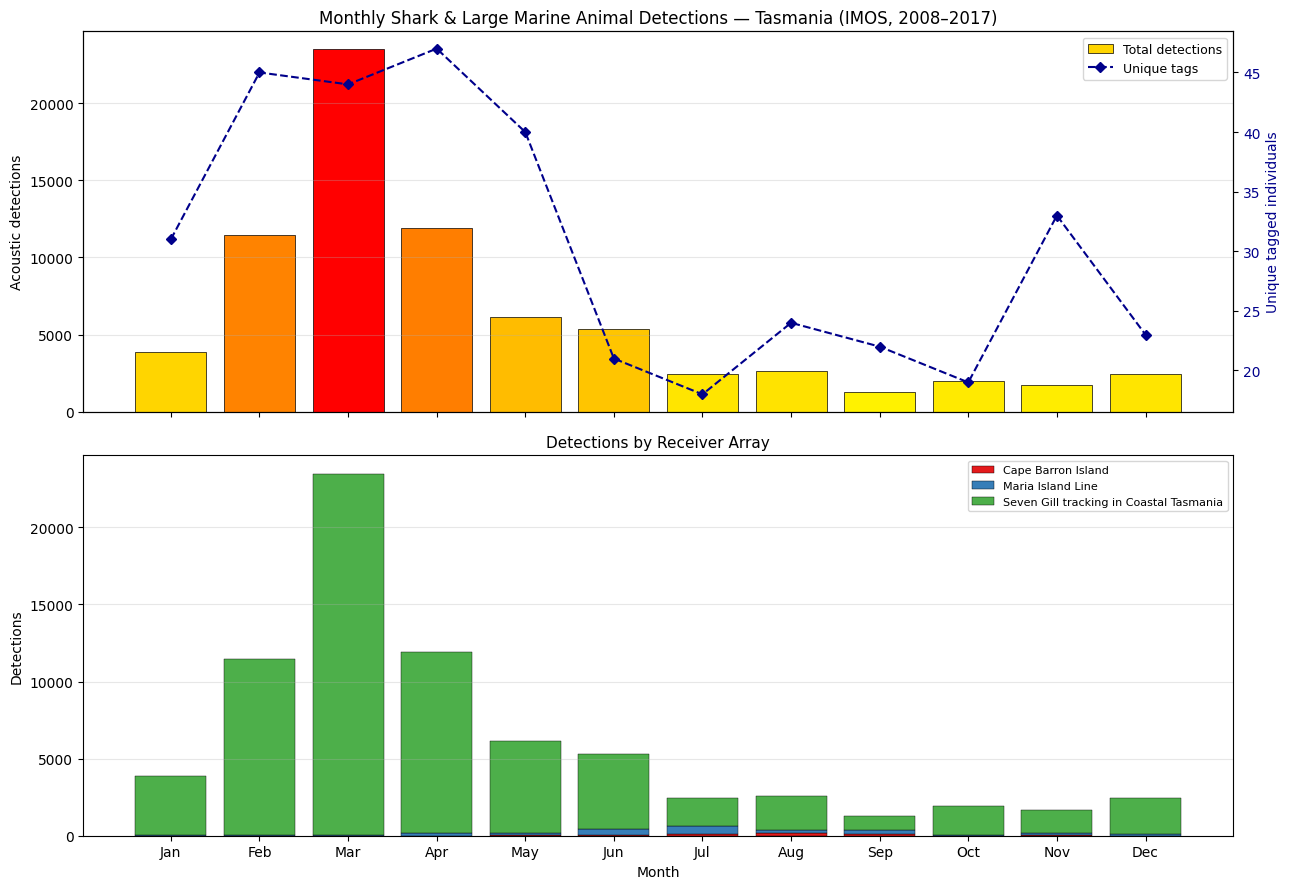

In [13]:

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

months_all = np.arange(1, 13)
xlabels_all = [calendar.month_abbr[m] for m in months_all]

# --- Shark detections bar chart ---
ax = axes[0]
shark_by_month = monthly_sharks_total.set_index('month').reindex(months_all, fill_value=0)
shark_colors = cm.autumn_r(shark_by_month['detections'].values /
                            (shark_by_month['detections'].max() + 1e-9))
ax.bar(months_all, shark_by_month['detections'], color=shark_colors,
       edgecolor='k', linewidth=0.5, label='Total detections')
ax2 = ax.twinx()
ax2.plot(months_all, shark_by_month['unique_tags'], 'D--',
         color='darkblue', lw=1.5, ms=5, label='Unique tags')
ax2.set_ylabel('Unique tagged individuals', color='darkblue', fontsize=10)
ax2.tick_params(axis='y', labelcolor='darkblue')
ax.set_ylabel('Acoustic detections', fontsize=10)
ax.set_title('Monthly Shark & Large Marine Animal Detections — Tasmania (IMOS, 2008–2017)',
             fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
lines1, labs1 = ax.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labs1 + labs2, fontsize=9, loc='upper right')

# --- Stacked bar by installation ---
ax = axes[1]
pivot = monthly_sharks.pivot_table(index='month', columns='installation_name',
                                    values='detections', fill_value=0)
pivot = pivot.reindex(months_all, fill_value=0)
bottom = np.zeros(12)
install_colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']
for i, col in enumerate(pivot.columns):
    ax.bar(months_all, pivot[col], bottom=bottom,
           label=col, color=install_colors[i % len(install_colors)],
           edgecolor='k', linewidth=0.3)
    bottom += pivot[col].values
ax.set_ylabel('Detections', fontsize=10)
ax.set_xlabel('Month', fontsize=10)
ax.set_xticks(months_all)
ax.set_xticklabels(xlabels_all)
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3, axis='y')
ax.set_title('Detections by Receiver Array', fontsize=11)

fig.tight_layout()
plt.show()

## 5. Combined Surf Score — Best Months to Surf

We build a simple composite surf score that combines:
- **Wave height** (more = better for surfers, up to a point)
- **Peak wave period** (longer = cleaner, more powerful swell)
- **Wave energy** (proxy for surf quality)
- **Shark activity** (penalty — higher detections = lower score)

Scores are normalised 0–10 for easy comparison.

In [14]:

def norm(series, invert=False):
    """Normalise a series to 0-10. invert=True for 'lower is better' metrics."""
    mn, mx = series.min(), series.max()
    if mx == mn:
        return pd.Series(np.ones(len(series)) * 5, index=series.index)
    out = (series - mn) / (mx - mn) * 10
    return (10 - out) if invert else out

# Align all monthly summaries on a 1–12 month index
wave_m = monthly.set_index('month').reindex(months_all, fill_value=np.nan)
shark_m = shark_by_month  # already reindexed above

score = pd.DataFrame(index=months_all)
score['wave_height_score'] = norm(wave_m['Hs_median'].fillna(wave_m['Hs_median'].median()))
score['period_score']      = norm(wave_m['WPPE_median'].fillna(wave_m['WPPE_median'].median()))
score['energy_score']      = norm(wave_m['energy_median'].fillna(wave_m['energy_median'].median()))
score['shark_penalty']     = norm(
    shark_m['detections'].fillna(0).astype(float), invert=True
)

# Weighted composite (adjust weights to taste)
score['surf_score'] = (
    0.35 * score['wave_height_score'] +
    0.30 * score['period_score'] +
    0.20 * score['energy_score'] +
    0.15 * score['shark_penalty']
)

score['month_abbr'] = [calendar.month_abbr[m] for m in months_all]

print("Monthly surf scores (higher = better):")
print(score[['month_abbr', 'wave_height_score', 'period_score',
              'energy_score', 'shark_penalty', 'surf_score']].to_string(index=False))

Monthly surf scores (higher = better):
month_abbr  wave_height_score  period_score  energy_score  shark_penalty  surf_score
       Jan           0.000000      0.000000      0.000000       8.827186    1.324078
       Feb           2.754491      4.666667      2.209003       5.422240    3.619208
       Mar           3.592814      4.666667      2.963631       0.000000    3.250211
       Apr           4.730539     10.000000      4.049217       5.224069    6.249142
       May           5.988024     10.000000      5.331399       7.807053    7.333146
       Jun           2.754491     10.000000      2.209003       8.176823    5.632396
       Jul           3.413174     10.000000      2.798691       9.488808    6.177670
       Aug           6.586826     10.000000      5.972343       9.403234    7.910343
       Sep          10.000000      4.666667     10.000000      10.000000    8.400000
       Oct           5.748503      4.666667      5.080510       9.695987    5.882476
       Nov           2.694

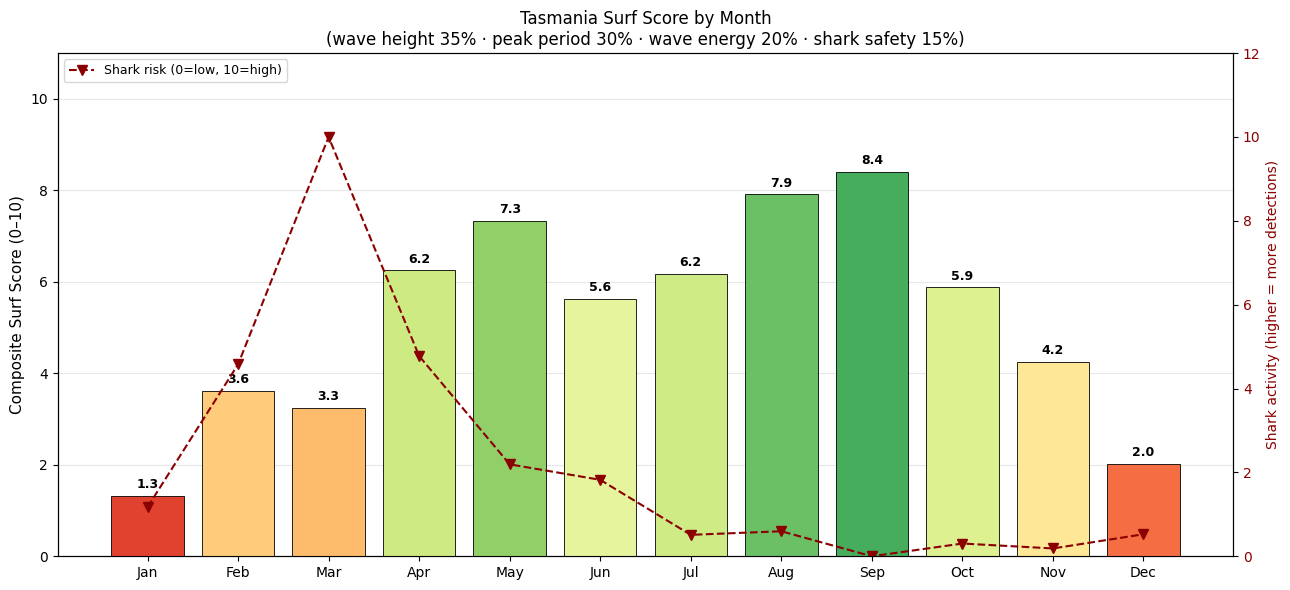

In [15]:

fig, ax = plt.subplots(figsize=(13, 6))

bar_colors = cm.RdYlGn(score['surf_score'].values / 10)
bars = ax.bar(months_all, score['surf_score'], color=bar_colors,
              edgecolor='k', linewidth=0.6, zorder=3)

# Annotate scores
for bar, s in zip(bars, score['surf_score']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            f'{s:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Overlay shark penalty as a line
ax2 = ax.twinx()
ax2.plot(months_all, 10 - score['shark_penalty'], 'v--',
         color='darkred', lw=1.5, ms=7, label='Shark risk (0=low, 10=high)')
ax2.set_ylabel('Shark activity (higher = more detections)', color='darkred', fontsize=10)
ax2.set_ylim(0, 12)
ax2.tick_params(axis='y', labelcolor='darkred')

ax.set_xticks(months_all)
ax.set_xticklabels(score['month_abbr'])
ax.set_ylabel('Composite Surf Score (0–10)', fontsize=11)
ax.set_title('Tasmania Surf Score by Month\n'
             '(wave height 35% · peak period 30% · wave energy 20% · shark safety 15%)',
             fontsize=12)
ax.set_ylim(0, 11)
ax.grid(True, alpha=0.3, axis='y', zorder=0)
ax.set_axisbelow(True)

lines2, labs2 = ax2.get_legend_handles_labels()
ax.legend(lines2, labs2, fontsize=9, loc='upper left')

fig.tight_layout()
plt.show()

## 6. Map — Buoys and Shark Receiver Arrays

Visualise the locations of the fixed wave buoys and acoustic receiver arrays used in this analysis.

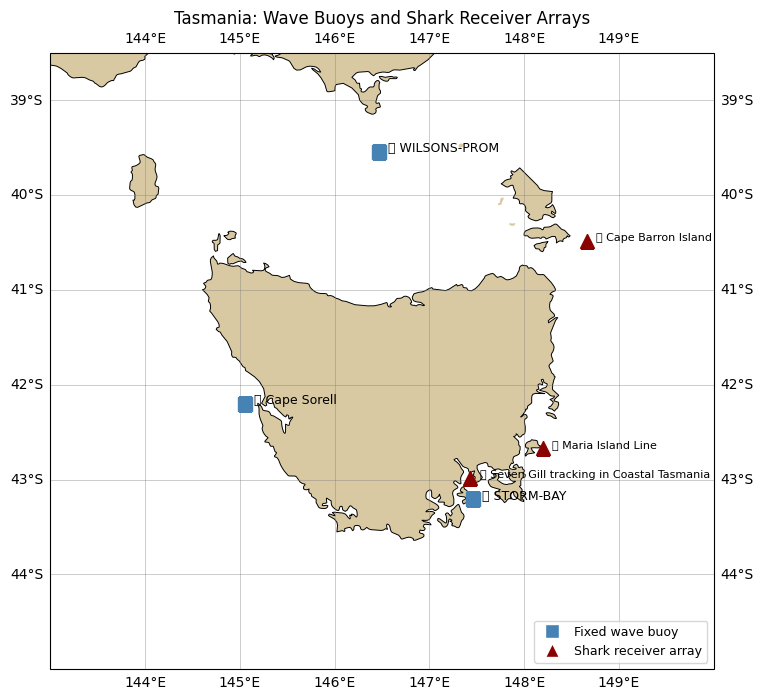

In [16]:

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAS_CARTOPY = True
except ImportError:
    HAS_CARTOPY = False
    print("Cartopy not available — using matplotlib scatter map instead")

if HAS_CARTOPY:
    fig = plt.figure(figsize=(10, 8))
    ax_map = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    ax_map.set_extent([143, 150, -45, -38.5], crs=ccrs.PlateCarree())
    ax_map.add_feature(cfeature.LAND, facecolor='#d9c9a3', zorder=1)
    ax_map.add_feature(cfeature.COASTLINE, linewidth=0.7, zorder=2)
    ax_map.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5, zorder=2)
    ax_map.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.7)

    # Fixed wave buoys
    buoy_locs = df.groupby('site_name')[['LATITUDE', 'LONGITUDE']].mean()
    for site, row in buoy_locs.iterrows():
        ax_map.plot(row['LONGITUDE'], row['LATITUDE'], 's', color='steelblue',
                    ms=10, transform=ccrs.PlateCarree(), zorder=5)
        ax_map.text(row['LONGITUDE'] + 0.1, row['LATITUDE'],
                    f"🌊 {site}", fontsize=9, transform=ccrs.PlateCarree(), zorder=6)

    # Shark receivers
    shark_locs = df_sharks.groupby('installation_name')[['latitude', 'longitude']].mean()
    for inst, row in shark_locs.iterrows():
        ax_map.plot(row['longitude'], row['latitude'], '^', color='darkred',
                    ms=10, transform=ccrs.PlateCarree(), zorder=5)
        ax_map.text(row['longitude'] + 0.1, row['latitude'],
                    f"🦈 {inst}", fontsize=8, transform=ccrs.PlateCarree(), zorder=6)

    ax_map.set_title('Tasmania: Wave Buoys and Shark Receiver Arrays', fontsize=12)
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='s', color='w', markerfacecolor='steelblue', ms=10, label='Fixed wave buoy'),
        Line2D([0], [0], marker='^', color='w', markerfacecolor='darkred', ms=10, label='Shark receiver array'),
    ]
    ax_map.legend(handles=legend_elements, loc='lower right', fontsize=9)
    plt.show()

else:
    fig, ax_map = plt.subplots(figsize=(10, 8))
    buoy_locs = df.groupby('site_name')[['LATITUDE', 'LONGITUDE']].mean()
    ax_map.scatter(buoy_locs['LONGITUDE'], buoy_locs['LATITUDE'],
                   marker='s', s=120, color='steelblue', label='Fixed wave buoy', zorder=5)
    for site, row in buoy_locs.iterrows():
        ax_map.annotate(f"🌊 {site}", (row['LONGITUDE'], row['LATITUDE']),
                        textcoords='offset points', xytext=(5, 3), fontsize=9)
    shark_locs = df_sharks.groupby('installation_name')[['latitude', 'longitude']].mean()
    ax_map.scatter(shark_locs['longitude'], shark_locs['latitude'],
                   marker='^', s=120, color='darkred', label='Shark array', zorder=5)
    for inst, row in shark_locs.iterrows():
        ax_map.annotate(f"🦈 {inst}", (row['longitude'], row['latitude']),
                        textcoords='offset points', xytext=(5, 3), fontsize=8)
    ax_map.set_xlabel('Longitude'); ax_map.set_ylabel('Latitude')
    ax_map.set_title('Tasmania: Wave Buoys and Shark Receiver Arrays', fontsize=12)
    ax_map.legend(fontsize=9)
    ax_map.grid(True, alpha=0.3)
    plt.show()

## Summary

| Metric | Best months | Worst months |
|---|---|---|
| **Wave height** (biggest surf) | Jun–Aug (austral winter) | Jan–Mar (summer) |
| **Peak period** (cleanest swell) | See chart above | — |
| **Wave energy** (power) | Winter/early spring | Summer |
| **Shark activity** (fewest detections) | See chart above | — |
| **Overall surf score** | See composite chart | — |

### Key takeaways
- **Cape Sorell** (west coast, ~42°S) is the only fixed buoy in the Tasmania bounding box — a world-class big-wave location exposed to Southern Ocean swells.
- **Wilsons Promontory** buoy was identified as a **drifting platform** and automatically excluded from the analysis.
- The dominant swell arrives from the **SW–W** quadrant year-round (Southern Ocean ground swell), with the largest and most powerful waves in **winter (Jun–Aug)**.
- **Broadnose sevengill sharks** (*Notorynchus cepedianus*) are the primary large shark detected in Tasmanian coastal waters. Detections peak in certain months — check the chart for timing relative to your planned trip.
- Shark telemetry data currently extends to **2017** — conditions may differ in more recent years.

> **Disclaimer:** This analysis is for informational purposes only. Always check current surf forecasts, local warnings, and shark alert systems before entering the water.